# Querying Materials Project data in the PSDI datalake using Ibis

In this notebook we use [Ibis](https://ibis-project.org/) to query tables in PSDI's lakehouse containing data from the [Materials Project](https://materialsproject.org).

---
## 1. Prerequisites

The following command installs the packages required for this notebook via `pip`:

In [1]:
!pip install -q trino matplotlib pandas "ibis-framework[trino]"

Now import the required resources:

In [9]:
import ibis
from ibis.backends.trino import Backend

from trino.dbapi import connect
from trino.auth import OAuth2Authentication

import pandas as pd   # Used for clearer output in the tutorial
from pprint import pprint  # Used for clearer output in the tutorial

import matplotlib.pyplot as plt

---
## 2. Set up

To query the data we use PSDI's [Trino](https://trino.io/) server to process our queries. This Trino server acts as a middleman between us and the data. Our Ibis queries will be passed to Trino. Trino, which has direct access to the data (while we do not), will then process the query, compile the results, and pass the results back to us.

First we must establish a connection with PSDI's Trino. Then we must link Ibis to this connection. Run the cell below to do this. 

In [27]:
TRINO_HOST = "trino-staging.psdi.ac.uk"

conn = connect(
    host=TRINO_HOST,
    port=443,
    http_scheme="https",
    auth=OAuth2Authentication(),
    catalog="psdi",
    request_timeout=300,
)

# Hand the live Trino connection to Ibis
con = Backend.from_connection(conn)

Note that the first time you run a query through this connection you will be prompted to authenticate via the PSDI Authentification system in your browser. 

To check the connection, let's try to list the available databases in the `psdi` catalog. As mentioned above, you may be prompted to authenticate.

In [28]:
con.list_databases(catalog="psdi")

Open the following URL in browser for the external authentication:
https://trino-staging.psdi.ac.uk/oauth2/token/initiate/6d28bfdfde7a6554f8e95a3e26c63c29960667bbb5fea1f6fedb06241bced65c


['information_schema',
 'materials_project',
 'materials_project_contribs',
 'materials_project_contribs.matpes',
 'materials_project_contribs.mptrj',
 'omat24',
 'omol25',
 'pubchem',
 'system']

---
## 3. Exploring the data

Here we use the Materials Project's [AWS Open Data](https://materialsproject-build.s3.amazonaws.com/index.html). To elaborate, PSDI has taken various 'collections' of the [build data](https://materialsproject-build.s3.amazonaws.com/index.html) (which is provided in JSONL format) and converted them in to tables. (See [here](https://materialsproject-build.s3.amazonaws.com/index.html#collections/) to see the list of collections). We will query those tables.

Various 'catalogs' are available through PSDI's Trino. The tables pertinent to this notebook are located in the `materials_project` database (where 'database' in this context means 'collection of tables') within the `psdi` catalog. Note that each table in the `materials_project` database corresponds to a 'collection' in the [build data](https://materialsproject-build.s3.amazonaws.com/index.html); e.g. the `absorption_flattened` table corresponds to the `absorption` collection.

The following code lists all the tables in the `materials_project` database.

In [11]:
tables = con.list_tables(database="materials_project")
pprint(tables)

['absorption_flattened',
 'absorption_flattened_v3',
 'alloy_pair_members_flattened',
 'alloy_pairs_flattened',
 'alloy_systems_flattened',
 'alloys_flattened',
 'chemenv_flattened',
 'dielectric_flattened',
 'elasticity_flattened',
 'insertion_electrodes_flattened',
 'magnetism_flattened',
 'oxi_states_flattened',
 'phonon_flattened',
 'piezoelectric_flattened',
 'provenance_flattened',
 'robocrys_flattened',
 'structure_groups_flattened',
 'task_validation_flattened',
 'task_validation_flattened_v3']


To create a variable linked to a table, `con.table(...)` can be used. E.g.

In [12]:
dielectric_table = con.table("dielectric_flattened", database="materials_project")

Open the following URL in browser for the external authentication:
https://trino-dev.psdi.ac.uk/oauth2/token/initiate/70d02fcf6be5e7dc69815575c3446dc75b788575d79298d4d583472366868db4


### List columns in a table

The *schema* of a table, i.e. its column names and data types (and often other information about columns) can be determined using `.schema()`. Below we use this to retrieve the schema of the `absorption_flattened` table. 

In [14]:
absorption_table = con.table("absorption_flattened", database="materials_project")
print(absorption_table.schema())

ibis.Schema {
  nsites                         int64
  elements                       string
  nelements                      int64
  formula_pretty                 string
  formula_anonymous              string
  chemsys                        string
  volume                         float64
  density                        float64
  density_atomic                 float64
  property_name                  string
  material_id                    string
  deprecated                     boolean
  deprecation_reasons            string
  origins                        string
  warnings                       string
  task_id                        string
  energies                       string
  energy_max                     float64
  absorption_coefficient         string
  average_imaginary_dielectric   string
  average_real_dielectric        string
  bandgap                        float64
  nkpoints                       int64
  sourced_from_path              string
  builder_meta.emmet_ve

---
## 4. Making graphs using data from the columns

Assuming we know what columns we are interested in, we can combine columns, including columns from different tables, to make graphs showing correlations in materials properties. Note that the `material_id` column will be crucial to combining data from different tables, since this is a unique tag of a material in the Materials Projet

### Plotting data from a single table

Below are code snippets which plot two columns from the `absorption_flattened` table. First we plot `bandgap` versus `density`. 

Note that we are using `select` to filter out only the pertinent columns of the table, and `to_pandas()` to export the result of the filter to a Pandas DataFrame. Data in the DataFrame is then plotted. We do this a lot in the rest of this notebook.

Open the following URL in browser for the external authentication:
https://trino-dev.psdi.ac.uk/oauth2/token/initiate/5f79f1eb82d9b52a8a65d86e290c0a34f67385ecfe77f68675b828ae84c8aa1f


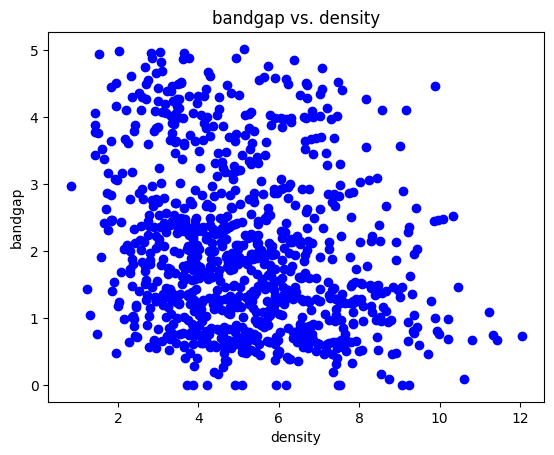

In [15]:
absorption_table = con.table("absorption_flattened", database="materials_project")
result = absorption_table.select("density", "bandgap")
df = result.to_pandas()

plt.scatter(df['density'].tolist(),df['bandgap'].tolist(),color='blue',marker='o')
plt.title('bandgap vs. density')
plt.xlabel('density')
plt.ylabel('bandgap')
plt.show()

Below we instead plot `energy_max` versus `density`.

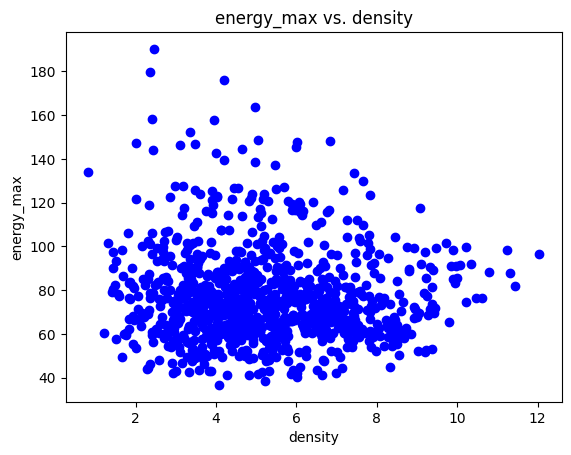

In [16]:
absorption_table = con.table("absorption_flattened", database="materials_project")
result = absorption_table.select("density", "energy_max")
df = result.to_pandas()

plt.scatter(df['density'].tolist(),df['energy_max'].tolist(),color='blue',marker='o')
plt.title('energy_max vs. density')
plt.xlabel('density')
plt.ylabel('energy_max')
plt.show()

### Joining and plotting data from different tables

Using a [SQL join](https://en.wikipedia.org/wiki/Join_(SQL)) operation over the `material_id` field we can combine data spread across many tables.

Below we plot the `density` (renamed as `rho`) obtained from the `absorption_flattened` table versus the density from the `magnetism_flattened` table - for all structures which appear in both tables.

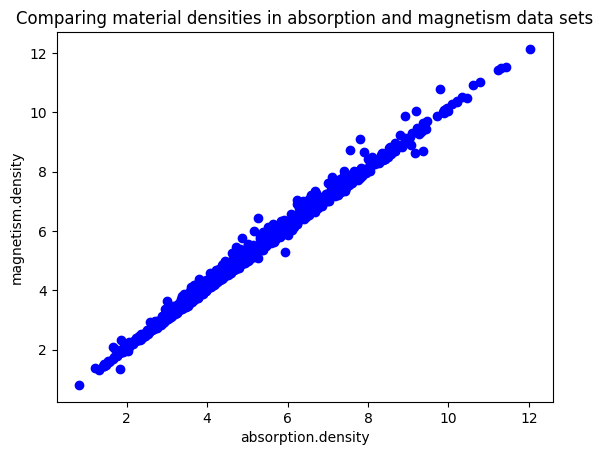

In [18]:
absorption = con.table("absorption_flattened", database="materials_project")
magnetism= con.table("magnetism_flattened", database="materials_project")

result = (
    absorption
    .join(
        magnetism,
        absorption.material_id == magnetism.material_id,
        how="inner",
    )
    .select(
        absorption.density.name("absorption_rho"),
        magnetism.density.name("magnetism_rho"),
    )
)
df = result.to_pandas()

plt.scatter(df['absorption_rho'].tolist(),df['magnetism_rho'].tolist(),color='blue',marker='o')
plt.title('Comparing material densities in absorption and magnetism data sets')
plt.xlabel('absorption.density')
plt.ylabel('magnetism.density')
plt.show()

It is interesting that the densities from the two tables are not the same for a given structure.

Below we similarly plot the `density` obtained from the `absorption_flattened` table against the `bulk_modulus.voigt` property (renamed as `bulk_modulus`) in the `elasticity_flattened` table.

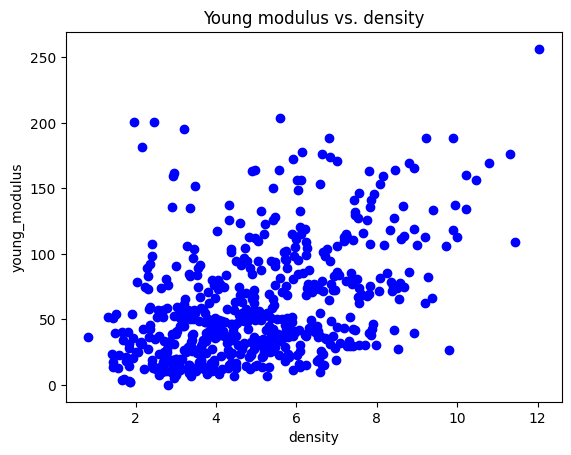

In [19]:
absorption = con.table("absorption_flattened", database="materials_project")
elasticity = con.table("elasticity_flattened", database="materials_project")

result = (
    absorption
    .join(
        elasticity,
        absorption.material_id == elasticity.material_id,
        how="inner",
    )
    .filter(
        elasticity["bulk_modulus.voigt"].notnull()
    )
    .select(
        absorption.density.name("density"),
        elasticity["bulk_modulus.voigt"].name("bulk_modulus"),
    )
)

df = result.to_pandas()

plt.scatter(df['density'].tolist(),df['bulk_modulus'].tolist(),color='blue',marker='o')
plt.title('Young modulus vs. density')
plt.xlabel('density')
plt.ylabel('young_modulus')
plt.show()

---
## 5. Ibis queries versus the Materials Project API

Examples of how to perform queries using the Materials Project API are given at https://docs.materialsproject.org/downloading-data/using-the-api/examples. 

Below we perform Ibis queries which reflect the aforementioned Materials Project API examples. Note that this is not a fair comparison since it is not like-for-like. For one thing the queries are on tables in the PSDI lakehouse derived from the 'build' open Materials Project data, not the 'main' Materials Project data which requires an API key to access.

### List the chemical formulae for all materials containing at least Si and O

This is the Materials Project API code for the 'summary' data set (which we do not consider here because it is too big for casual demonstrations):

```
from mp_api.client import MPRester

with MPRester("your_api_key_here") as mpr:
    docs = mpr.materials.summary.search(
        elements=["Si", "O"], fields=["material_id", "band_gap", "formula_pretty"]
    )
    mpid_formula_dict = {
        doc.material_id: doc.formula_pretty for doc in docs
    }
```

Below is an analogous Ibis query for the `dielectic_flattened` dataset. Note that I have exploited a regex to catch only the element symbol 'O' instead of using the glob pattern `%O%` which might match the element symbol 'Os' or 'Og'.

In [20]:
dielectric = con.table("dielectric_flattened", database="materials_project")

result = (
    dielectric
    .filter(
        dielectric.formula_pretty.like("%Si%")
        & dielectric.formula_pretty.re_search(r".*O[0-9]+.*")
    )
    .select(
        dielectric.formula_pretty,
        dielectric.material_id,
    )
)

df = result.to_pandas()
print(df)

Open the following URL in browser for the external authentication:
https://trino-dev.psdi.ac.uk/oauth2/token/initiate/779992eabc50ba51c09f06bf2502103df20560f84099fd58e13e7cc3cf204752
          formula_pretty material_id
0               LiGaSiO4    mp-18147
1               LiAlSiO4    mp-18220
2               Li2VSiO5    mp-18860
3              Na2TiSiO5     mp-6138
4               LiAlSiO4   mp-556544
..                   ...         ...
266                 SiO2   mp-669426
267      KNaMg2Si4(O5F)2   mp-561491
268     Na4Ga3Si3B(HO3)4   mp-534870
269      Na4BeAlSi4ClO12    mp-23151
270  Na8BeAl4Si7(ClO12)2    mp-42583

[271 rows x 2 columns]


### List the band gaps for all materials containing only Si and O

This is the Materials Project API code:

```
from mp_api.client import MPRester

with MPRester("your_api_key_here") as mpr:
    docs = mpr.materials.summary.search(
        chemsys="Si-O", fields=["material_id", "band_gap"]
    )
    mpid_bgap_dict = {doc.material_id: doc.band_gap for doc in docs}
```

Below is an analogous query for the `absorption_flattened` data set. Note that we are using regular expression searches to find chemical formulae which contain`Si` and `O` (but not `Os` or `Og`).

In [21]:
absorption = con.table("absorption_flattened", database="materials_project")

result = (
    absorption
    .filter(
        absorption.formula_pretty.re_search(r"Si")
        & absorption.formula_pretty.re_search(r"O[^sg]*")
    )
    .select(
        absorption.formula_pretty,
        absorption.material_id,
        absorption.bandgap,
    )
)

df = result.to_pandas()
print(df)

  formula_pretty material_id  bandgap
0         YbSiO3  mp-1187516   4.1063


### Find all Materials Project IDs for entries with dielectric data

This is the Materials Project API code given in the documentation:
```
from mp_api.client import MPRester
from emmet.core.summary import HasProps

with MPRester("your_api_key_here") as mpr:
    docs = mpr.materials.summary.search(
        has_props = [HasProps.dielectric], fields=["material_id"]
    )
    mpids = [doc.material_id for doc in docs]
```
Below is an analogous query.

In [25]:
dielectric = con.table("dielectric_flattened", database="materials_project")

result = dielectric.select(dielectric.material_id)

df = result.to_pandas()
print(df)

     material_id
0     mp-1045241
1     mp-1048318
2     mp-1078244
3     mp-1078367
4       mp-11016
...          ...
7327   mp-999498
7328   mp-990424
7329   mp-632250
7330   mp-542605
7331   mp-558014

[7332 rows x 1 columns]
